# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   | X       |
|------------|---------|
| Tushit Jain  | 6233384 |
| Lukáš Kubis  | 6207618 |
| Xianfei Kong  | 6127339 |
| Alex Ion  | 6138101 |

#### Imports

In [1]:
from scipy.spatial.distance import euclidean

"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData
from Visualizer import Visualizer

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

The Travelling Salsemen Problem is an NP hard combinatorial optimization problem that asks: Given a list of cities and the distances between each pair of cites, what is the shortest possible route that visits each city exactly once and returns to the original sity.

Referance: https://en.wikipedia.org/wiki/Travelling_salesman_problem

#### Question 2

The first way in which our problem is fundamentally different comes from the definition of the Travelling Salseman Problem. It states that the shortest route is expected to return to it's original state/city, where it started from. However, our robot is expected to start at some start locaiton, pick up all products and end at a location that is potentially different from the start, thus not returning to where it started from.

The second difference comes from what data is available to us to solve this problem. Here, we are given an optimal route between each pair of cities, however in a classical TSP this data is also unknown. This makes solving this perticular problem a little bit easier, as the search space is significantly smaller. A third smaller difference is that in a classical TSP, the distance between cities is represented as a straight line Euclidean distance. However in our maze, the distance between two objects is represented as the steps taken in total in one of the four cardinal directions, representing the manhatten distance, which is a different distance measure.

#### Question 3

Compututational intelligence techniques, in our specific case genetic algorithms for example, are appropriate to solve NP-hard problems such as TSP as they provide a smart way to navigate the absolutely huge search space. As there are so many routes in a TSP, it is nearly impossible for bigger problems to go through all routs and find a globally optimal solution, and thus CI algorithms allow us to smarlty recover a near optimal solution, with less compute.

In the example of Genetic Algorithms, an important characteristic that makes such problems solvable is the idea that it is Stochastic, and adds controlled randomness in it's search, through mutation and crossover. This allows the CI algorithm to potentially jump out of local optima in search of better optimal solution. Another characteristic of GA's for example is the fitness based selection, which allows the algorithm to keep shorter routes during its search while discarding longer routes, making the search space smaller. This guides the search faster towards the optimum without needing to know where the optimum actually is.

### 1.2 Genetic Algorithm

In [ ]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    """
    def __init__(self, generations, pop_size, mutation_prob, crossover_prob):
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_prob = mutation_prob
        self.crossover_prob = crossover_prob
    
    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        tsp_data.build_distance_lists()
        self.distance_matrix = tsp_data.get_distances()
        self.start_distances = tsp_data.get_start_distances()
        self.end_distances = tsp_data.get_end_distances()
        self.chromosome_length = len(self.distance_matrix)
        self.population = self.initialise_population(self.chromosome_length)

        best_individual = None
        best_fitness = -1

        for gen in range(self.generations):
            fitness_scores = [self.fitness(individual) for individual in self.population]
            sorted_indices = sorted(range(self.pop_size), key = lambda i: fitness_scores[i], reverse=True)

            first_fittest = sorted_indices[0]
            second_fittest = sorted_indices[1]
            new_population = [self.population[first_fittest][:], self.population[second_fittest][:]]

            # for testing, printing fittest individual
            if (fitness_scores[first_fittest] > best_fitness):
                best_fitness = fitness_scores[first_fittest]
                best_individual = self.population[first_fittest][:]

            while len(new_population) < self.pop_size:
                parent1 = self.binary_tournament_selection(fitness_scores)
                parent2 = self.binary_tournament_selection(fitness_scores)
                child1, child2 = self.ordered_crossover(parent1, parent2)
                new_population.append(self.mutate(child1))
                new_population.append(self.mutate(child2))
            
            self.population = new_population
        return best_individual

    """
    This method creates the initial population of size pop_size.
    Each individual's chromosome is an array containing products 0 to pop_size - 1 in a random order.
    @return the entire initial population as an array contianing chromosomes of each individiual.
    """
    def initialise_population(self, n):
        return [random.sample(range(n), n) for _ in range(self.pop_size)]
    
    """
    This method is responsible for adding mutations to an individual.
    Here, a mutation is swapping two indecies, which corresponds with swapping positions of two products in a path.
    @param individual: the individual we want to mutate.
    @return the individual which may or may not have been mutated.
    """
    def mutate(self, individual):
        if random.random() < self.mutation_prob:
            i, j = random.sample(range(self.chromosome_length), 2)
            individual[i], individual[j] = individual[j], individual[i]
        return individual


    """
    This method applies ordered crossover to two parents resulting in two new individuals.
    @return two new individuals based on the parents genes
    """
    def ordered_crossover(self, parent1, parent2):
        if (random.random() >= self.crossover_prob): 
            return parent1, parent2
        start_index, end_index = sorted(random.sample(range(self.chromosome_length), 2))
        child1 = [-1] * self.chromosome_length
        child2 = [-1] * self.chromosome_length
        child1[start_index:end_index] = parent1[start_index:end_index]
        child2[start_index:end_index] = parent2[start_index:end_index]
        parent1_pointer = end_index
        parent2_pointer = end_index
        filled_genes_child1 = set(child1[start_index:end_index])
        filled_genes_child2 = set(child2[start_index:end_index])
        for i in range(self.chromosome_length - (end_index - start_index)):
            child1_index = (end_index + i) % self.chromosome_length
            while parent2[parent2_pointer % self.chromosome_length] in filled_genes_child1:
                parent2_pointer += 1
            child1[child1_index] = parent2[parent2_pointer % self.chromosome_length]
            filled_genes_child1.add(parent2[parent2_pointer % self.chromosome_length])
        for j in range(self.chromosome_length - (end_index - start_index)):
            child2_index = (end_index + j) % self.chromosome_length
            while parent1[parent1_pointer % self.chromosome_length] in filled_genes_child2:
                parent1_pointer += 1
            child2[child2_index] = parent1[parent1_pointer % self.chromosome_length]
            filled_genes_child2.add(parent1[parent1_pointer % self.chromosome_length])
        return child1, child2



    """
    Calculates the fitness of a given individual. Here the fitness is defined as 1/sum of pairwise distances.
    @param individual: the individual for which we are calculating the fitness
    @return the fitness of this individual
    """
    def fitness(self, individual):
        total_distance = 0
        current_node_index = 0
        next_node_index = 1
        total_distance += self.start_distances[individual[0]]
        while(next_node_index < self.chromosome_length):
            current_product = individual[current_node_index]
            next_product = individual[next_node_index]
            total_distance += self.distance_matrix[current_product][next_product]
            current_node_index += 1
            next_node_index += 1
        total_distance += self.end_distances[individual[self.chromosome_length - 1]]
        return 1/total_distance
    

    """
    This method is responsible for implementing binary tournament selection on the population.
    It picks two candidates at random and returns the individual with the higher fitness.
    @return the chosen candidate
    """
    def binary_tournament_selection(self, fitness_scores):
        candidate_one_index, candidate_two_index = random.sample(range(self.pop_size), 2)
        if (fitness_scores[candidate_one_index] > fitness_scores[candidate_two_index]):
            return self.population[candidate_one_index][:]
        else:
            return self.population[candidate_two_index][:]

#### Question 4

The genes here represent a possible order in which to collect the products. In order to encode this into the chromosomes, we will initialise them as an array containing integers 0 to n - 1, where n is the number of products to pick up. These chromosomes will be random permutations of these n - 1 integers in the array.

#### Question 5

The fitness funcition we opted for is the total distance covered by the robot from the start to the end in picking up these n products, as this is the parameter we are trying to minimize. For Genetic Algorithm's it is standard that the fittest individual is the one that maximizes the fitness funciton, and thus the actual fitness funciton for our GA is 1/(total distance), which we aim to maximize.

#### Question 6

In our implementation of the GA, the parents for the next generation population are chosen using Binary Tournament Seleciton. This method let's individuals with best routes a high chance to pass over their genes, but still allows mediocre routes to pass on their genes.

#### Question 7

We chose to implement mutations and crossovers as genetic operations. Mutation allows stochasticity in our search, certain genes have low probability of mutating, and switiching the position of two products in the route. This is part of the exploration phase and prevents premature convergance by preventing the population convergin in essence to a similar gene and end up in a local optimum. In addition, crossover allows the algorithm to preserve optimal suroutes by ensuring that these subroutes are part of the next population. In particular, our algorithm implements the ordered crossover of genes between two parents.

#### Question 8

We prevent getting stuck in local minima buy applying mutation to keep the population diverse, such that there is a change to explore possibly worse routes in hopes a better route is found. Furthermore, implementing a binary tournament selection and not a higher k-ary selection makes it possible for non-optimal routes to reproduce and go through mutation and crossover in hopes for climbing out of the local minima.

#### Question 9

Eletism is the practise of carrying over the best individuals from the current generation into the next generation in a Genetic algorithm. Yes we have implemented a minimal case of Eletism, in particular always keeping the top 2 fittest individuals. This helps preserving the current shortest routes found and not having them lost in the upcoming generations.

#### Question 10

In [ ]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 50
generations = 5000
random.seed(50)
mutation_prob = 0.1
crossover_prob = 0.8
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size, mutation_prob, crossover_prob)

# Run optimzation and write to file
solution = ga.solve_tsp(tsp_data)
print(solution)
tsp_data.write_action_file(solution, "./../data/tsp_solution.txt")

[0, 1, 6, 4, 13, 15, 3, 8, 17, 7, 9, 14, 11, 12, 5, 10, 2, 16]


After running our Genetic Algorithm, our fittest individual has the following order of products: 0, 1, 6, 4, 13, 15, 3, 8, 17, 7, 9, 14, 11, 12, 5, 10, 2, 16. This gives us the distance of 1343, as can be seen in tsp_solution.txt. Although it is hard to say whether the solution is optimal, it is safe to say that monitoring the fitness scores of the different generations, the best fitness seems to converge to this score, 1343, and hence it leads us to believe that this is a near optimal solution.

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

<div style="">
The purpose of Ant Colony Optimization (ACO) is in general to solve optimization problems. It does this based on how real ants communicate, which is with the help of pheromones the deposit.
<br/>
<br/>
The usual settings where ACO is used are tasks in which the artificial ants have to find the shortest path to some goal. For example, the Travelling Salesman Problem, in which the goal is to find the shortest path such that all cities are visited exactly once.

#### Question 12

<div style="">

One 'topographical' feature of a maze that can make it difficult for an ant to find the exit is the number of dead ends between the starting point and the exit point. Since ants choose their paths probabilistically, if we increase the number of ways that the ants can go without reaching the end, we decrease the chance of them actually finding the exit. <br/>
<br/>
Another such feature is the overall complexity/size of the maze. This is because the more complex the maze is, the more iterations and ants the algorithm requires to eventually find the solution. If the maze is too difficult, the algorithm might not be feasible, and in the real world for too complex problems the basic algorithm is rarely used for very complex tasks.

#### Question 13

<div style="">

The equation used for the amount of dropped pheromone is:
$ \tau _{ij} = Q*\frac{1}{L^{k}} $ <br/>
Where $Q$ is a set value, and $ L^{k} $ is the length of route k.<br/>
<br/>
Ants need to drop pheromones because the next generation uses the amount of pheromones on each cell to calculate their probabilities and pick a path. As such, each ant in a generation needs to drop pheromones such that the next generation can pick a path next. In addition, without any pheromones added, the next generation would be picking randomly and then no real optimization would take place, the behavior of the ants being closer to a random walk than actually trying to find a path.

#### Question 14

<div style="">

The equation used is:
 $ \tau _{ij}=(1-\rho)*\tau_{ij} + \sum_{k=1}^{m}\Delta\tau_{ij}^{k} $ <br/>
 Where, $\rho$ is the evaporation constant (which usually has a value equal to 0.1, but can be changed), $\tau_{ij}$ is the amount of pheromones currently on the path, and $\sum_{k=1}^{m}\Delta\tau_{ij}^{k}$ is the total amount of pheromones added on this path.<br/> <br/>
 The amount of pheromones that evaporate is dependent on the value of $\rho$, since it dictates how much of the current amount of pheromones remains. In our implementation, we set the constant to 0.1, and as such we will have 0.1 of the pheromone evaporate before having more added by the other ants. <br/> <br/>
 The purpose of pheromone evaporation is making sure that the shortest (or the closest path to the shortest) remains at the end. This works because the longer paths will eventually have pheromones evaporate off of them, since ants will get to the shorter ones faster, and thus deposit more pheromones on the shorter ones.

### 2.3 Implementing the Ant Algorithm

In [ ]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification, alpha, beta, max_iter):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.alpha = alpha
        self.beta = beta
        self.rand = random
        self.max_iter = max_iter

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        last_visited = (self.start.x, self.start.y)
        step = 0
        # Loop until we find the exit or reach maximum steps (to prevent infinite loops)
        while self.current_position != self.end and step < self.max_iter:  # Adjust the maximum steps as needed
            step += 1
            #print("-----------------------------")
            # Get surrounding pheromones and possible directions
            surrounding = self.maze.get_surrounding_pheromone(self.current_position)
            directions = [Direction.east, Direction.north, Direction.west, Direction.south]
            probabilities = []
            for direction in directions:
                neighbor = self.current_position.add_direction(direction)
                #print(f"For direction {direction}, we are in neighbor: ({neighbor.x}, {neighbor.y})")
                # Check if we are still in the maze, and it is not a wall, and we didn't visit it
                if (self.maze.in_bounds(neighbor)
                        and self.maze.walls[neighbor.x][neighbor.y] == 1.0
                        and (neighbor.x, neighbor.y) != last_visited):
                    #print(f"We append the surrounding pheromones ({surrounding.get(direction)})")
                    tau = surrounding.get(direction)**self.alpha
                    #euclidean = np.sqrt((neighbor.x - self.end.x) ** 2 + (neighbor.y - self.end.y) ** 2)
                    #eta = (1.0 / euclidean) ** self.beta
                    eta = (1.0 / 1.0) ** self.beta #distance in maze is just 1
                    probabilities.append(tau*eta + 0.1)
                else:
                    #print("We are outside the maze so append 0.0")
                    probabilities.append(0.0)

            total = sum(probabilities)
            #print(f"Total is {total}")
            if total == 0.0:
                return None #ant is stuck

            probabilities = [prob / total for prob in probabilities]
            #print(f"Probabilities are {probabilities}")
            next_direction = self.rand.choices(directions, weights=probabilities, k=1)[0]
            #print(f"We picked the next direction to be {next_direction}")
            next_position = self.current_position.add_direction(next_direction)

            route.add(next_direction)
            last_visited = (self.current_position.x, self.current_position.y)
            self.current_position = next_position
        if(step >= self.max_iter):
            return None #ant is stuck
        return route



In [ ]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
from matplotlib import pyplot as plt


class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.pheromones = [[1.0] * self.length for _ in range(self.width)]
        self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        #self.pheromones = [[1]*self.length]*self.width
        self.pheromones = [[1.0] * self.length for _ in range(self.width)]

    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        if(len(route.get_route()) == 0):
            return
        deposit = q / len(route.get_route())
        position = route.get_start()
        for step in route.get_route():
            position = position.add_direction(step)
            if self.in_bounds(position):
                self.pheromones[position.x][position.y] += deposit

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        for i in range(self.width):
            for j in range(self.length):
                self.pheromones[i][j] *= (1.0-rho)

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns a the amount of pheromones on the neighbouring positions (N/S/E/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position):
        n_pher = self.get_pheromone(position.add_direction(Direction.north))
        s_pher = self.get_pheromone(position.add_direction(Direction.south))
        e_pher = self.get_pheromone(position.add_direction(Direction.east))
        w_pher = self.get_pheromone(position.add_direction(Direction.west))
        return SurroundingPheromone(n_pher,s_pher,e_pher,w_pher)

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified poition
    """
    def get_pheromone(self, pos):
        if 0 <= pos.x < self.width:
            if 0 <= pos.y < self.length:
                return self.pheromones[pos.x][pos.y]
        return 0.0

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

    """
    Method that visualizes the pheromone levels of the maze as a heatmap.
    This method was made with the assistance of AI.
    @return None, displays a matplotlib heatmap of the current pheromone state
    """
    def visualize_pheromones(self):
        grid = np.zeros((self.width, self.length))
        for x in range(self.width):
            for y in range(self.length):
                if self.walls[x][y] == 0:
                    grid[x][y] = -1  # wall
                else:
                    grid[x][y] = self.pheromones[x][y]

        grid = grid.T

        wall_mask = grid == -1
        zero_mask = (grid == 0.0) & ~wall_mask  # zero pheromone on accessible tiles
        pheromone_grid = np.where(wall_mask | zero_mask, np.nan, grid)

        fig, ax = plt.subplots(figsize=(6, 4))

        # Draw pheromone heatmap in green gradient
        im = ax.imshow(pheromone_grid, cmap='Greens', interpolation='nearest',
                    vmin=0, vmax=np.nanpercentile(pheromone_grid, 95))

        # Draw walls in black
        wall_display = np.where(wall_mask, 1.0, np.nan)
        ax.imshow(wall_display, cmap='gray', interpolation='nearest', vmin=0, vmax=1)

        # Draw zero pheromone tiles in red
        zero_display = np.where(zero_mask, 1.0, np.nan)
        ax.imshow(zero_display, cmap='autumn_r', interpolation='nearest', vmin=0, vmax=1)

        if self.start is not None:
            ax.plot(self.start.x, self.start.y, 'bs', markersize=10, label='Start')
        if self.end is not None:
            ax.plot(self.end.x, self.end.y, 'b*', markersize=12, label='End')

        plt.colorbar(im, ax=ax, label='Pheromone level')
        ax.set_title('Pheromone heatmap')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        if self.start is not None or self.end is not None:
            ax.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    @param stop_limit: the number of consecutive iterations without improvement in the shortest path before the algorithm stops
    @param max_iter: the maximum number of iterations for each ant to find a path (to prevent infinite loops)
    @param momentum: the momentum factor for the intelligent ant variant
    @param intelligent_ant: flag indicating whether to use the intelligent ant variant
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, alpha, beta, stop_limit, max_ant_iter, momentum, intelligent_ant = True):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.alpha = alpha
        self.beta = beta
        self.evaporation = evaporation
        self.stop_limit = stop_limit
        self.max_ant_iter = max_ant_iter
        self.momentum = momentum
        self.intelligent_ant = intelligent_ant

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification):
        self.maze.reset()
        shortest_route = Route(path_specification.get_start())
        shortest_length = float("inf")
        iterations_without_improvement = 0
        for g in range(self.generations):
            routes = []
            shortest_route_found = False
            for a in range(self.ants_per_gen):
                if self.intelligent_ant:
                    ant = IntelligentAnt(self.maze, path_specification, self.alpha, self.beta, self.max_ant_iter, self.momentum)
                    cur_route, negative_pheromone_tiles = ant.find_route()
                    for tile in negative_pheromone_tiles:
                        self.maze.pheromones[tile[0]][tile[1]] = 0.0
                else:
                    ant = StandardAnt(self.maze, path_specification, self.alpha, self.beta, self.max_ant_iter)
                    cur_route = ant.find_route()
                if cur_route is not None:
                    routes.append(cur_route)
                    cur_length = len(cur_route.get_route())
                    if cur_length < shortest_length:
                        shortest_length = cur_length
                        shortest_route = cur_route
                        shortest_route_found = True
            # Update pheromones
            self.maze.evaporate(self.evaporation)
            self.maze.add_pheromone_routes(routes, self.q)

            if shortest_route_found:
                iterations_without_improvement = 0
            else:
                iterations_without_improvement += 1
    
            # Convergence criterion
            if iterations_without_improvement > self.stop_limit:
                break
        return shortest_route


Ready reading maze file ./../data/easy_maze.txt
Start: 0, 0 End: 24, 14
Time taken: 6.385
Route size: 50


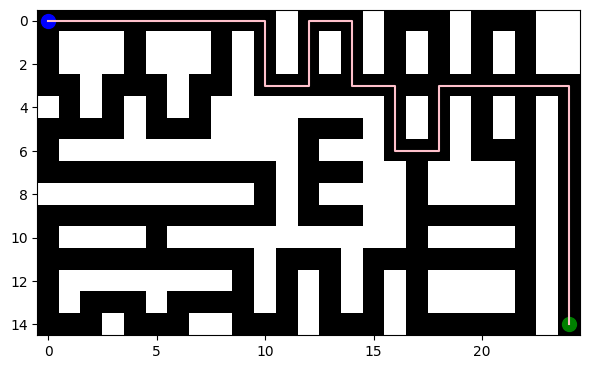

Pheromone levels at the end:


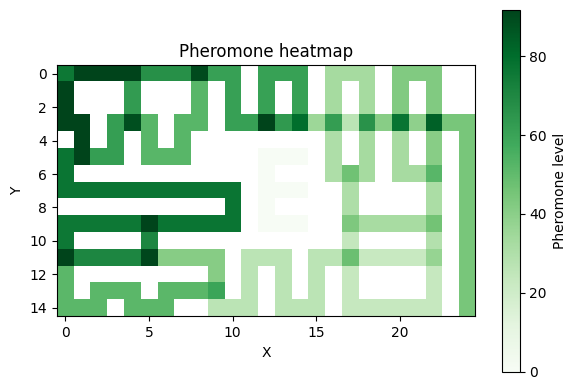

In [ ]:
# Please keep your parameters for the ACO easily changeable here
ants_per_gen = 50
no_gen = 150
q = 1000
evap = 0.1
max_ant_iter = 500
alpha = 1
beta = 2
stop_limit = 20
momentum = 1.5


# Construct the optimization objects
maze = Maze.create_maze("./../data/easy_maze.txt")
spec = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")

path_spec_string = spec.__str__()
print(path_spec_string)
aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_ant_iter, momentum, intelligent_ant = False)

start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))
Visualizer.visualize_individual_path(maze, shortest_route, spec)
print("Pheromone levels at the end:")
maze.visualize_pheromones()

### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [ ]:
# Class that represents the intelligent Ant
class IntelligentAnt:

    """
    Constructor of an IntelligentAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification, alpha, beta, max_ant_iter, momentum):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random
        self.alpha = alpha
        self.beta = beta
        self.max_ant_iter = max_ant_iter
        self.momentum = momentum

    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """

    def find_route(self):
        route = Route(self.start)
        negative_pheromone_tiles = []
        dfs_stack = []
        visited = set()
        last_visited = (self.start.x, self.start.y)
        visited.add(last_visited)
        current_direction = None
        num_steps = 0
        # Loop until we find the exit
        while self.current_position != self.end and num_steps < self.max_ant_iter:
            # Get surrounding pheromones and possible directions
            surrounding = self.maze.get_surrounding_pheromone(self.current_position)
            directions = [Direction.east, Direction.north, Direction.west, Direction.south]
            probabilities = []
            loop_found = False

            for direction in directions:
                neighbor = self.current_position.add_direction(direction)
                
                #check for the possibility of a loop
                if ((neighbor.x, neighbor.y) in visited
                    and (neighbor.x, neighbor.y) != last_visited):
                        loop_found = True
                        
                # Check if we are still in the maze, and it is not a wall, and we didn't visit it
                if (self.maze.in_bounds(neighbor)
                        and self.maze.walls[neighbor.x][neighbor.y] == 1.0
                        and (neighbor.x, neighbor.y) not in visited):
                    tau = surrounding.get(direction)**self.alpha
                    #euclidean = np.sqrt((neighbor.x - self.end.x) ** 2 + (neighbor.y - self.end.y) ** 2)
                    #eta = (1.0 / euclidean) ** self.beta
                    eta = (1.0 / 1.0) ** self.beta #distance in maze is just 1

                    momentum_bonus = self.momentum if direction == current_direction else 1.0
                    probabilities.append(tau*eta*momentum_bonus + 0.1)
                else:
                    probabilities.append(0.0)

            total = sum(probabilities)
            while total == 0.0:
                self.current_position, probabilities, current_direction, prev_num_steps = dfs_stack.pop()

                if(not loop_found):                    
                    # leaving negative pheromone on the tile to avoid other ants to get stuck in the same deadend
                    prev_next_position = self.current_position.add_direction(current_direction)
                    negative_pheromone_tiles.append((prev_next_position.x, prev_next_position.y))
                
                # backtrack to the position before the loop/dead end started
                for i in range(num_steps - prev_num_steps):
                    route.remove_last()
                num_steps = prev_num_steps
                
                # if all probabilities are zero, no path from current intersection leads to the exit, so it's a dead end.
                total = sum(probabilities)
                if(total == 0.0):
                    loop_found = False
            
            probabilities = [prob / total for prob in probabilities]
            next_direction = self.rand.choices(directions, weights=probabilities, k=1)[0]

            # avoid going back to the same position we just came from to prevent immediate loops
            probabilities[next_direction.value] = 0.0
            
            # storing the position and probabilities for backtracking
            if(any(p > 0 for p in probabilities)):
                dfs_stack.append((self.current_position, probabilities, next_direction, num_steps))

            route.add(next_direction)

            # moving to the next position
            next_position = self.current_position.add_direction(next_direction)
            last_visited = (self.current_position.x, self.current_position.y)
            self.current_position = next_position
            visited.add((self.current_position.x, self.current_position.y))

            # updating the last visited position and current direction for loop detection and momentum
            current_direction = next_direction
            num_steps += 1

        return (route, negative_pheromone_tiles)


##### Improvement 1: Full visited memory with dead-end marking
The standard ant only remembers the last visited tile, meaning it can revisit tiles and loop indefinitely. Our intelligent ant maintains a full set of all visited tiles preventing loops entirely. When stuck, it backtracks to the last intersection and marks the dead-end entry tile with zero pheromone, warning future ants away. This is biologically inspired by repellent pheromones some ant species use to signal danger.

We tested this on three custom mazes specifically designed to trigger dead-ends and loops. As shown in the pheromone heatmaps, the standard ant leaves diffuse pheromone trails across the whole maze while the intelligent ant converges strongly on the correct path (dark green) with dead-end tiles marked in red. Both find the same route length of 12, but the intelligent ant produces much cleaner pheromone trails that will guide future generations more effectively.


==================== dead_end_maze.txt ====================
Ready reading maze file ./../data/dead_end_maze.txt
========Standard Ant:
Time taken: 0.046
Route size: 12


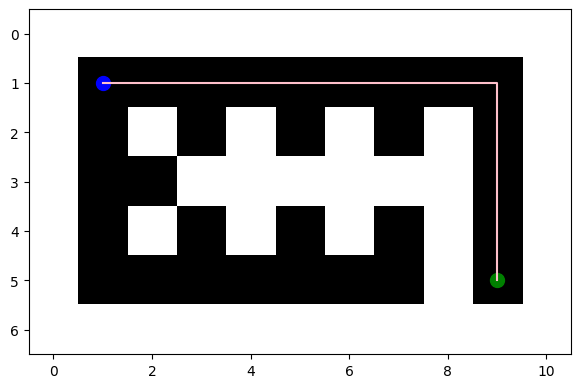

Pheromone levels at the end:


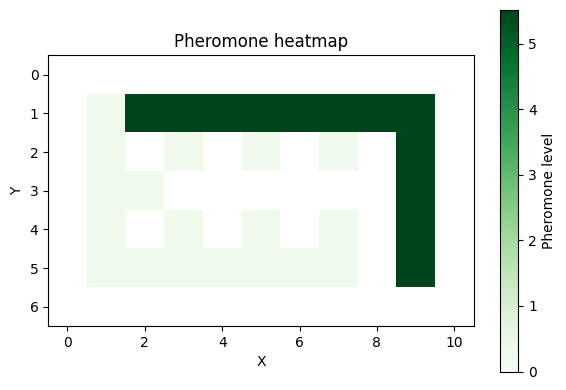


========Intelligent Ant:
Time taken: 0.239
Route size: 12


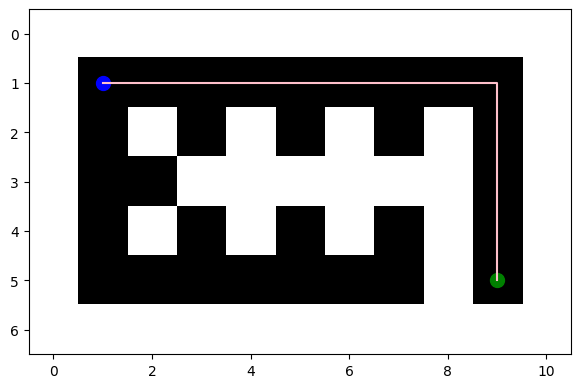

Pheromone levels at the end:


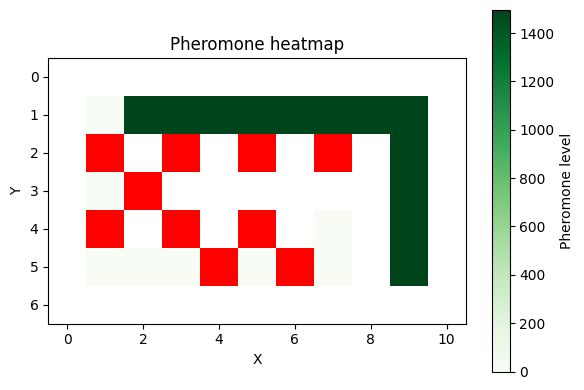


==================== loop_maze.txt ====================
Ready reading maze file ./../data/loop_maze.txt
========Standard Ant:
Time taken: 0.193
Route size: 12


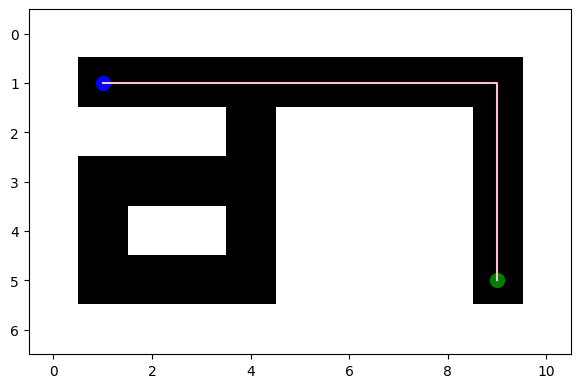

Pheromone levels at the end:


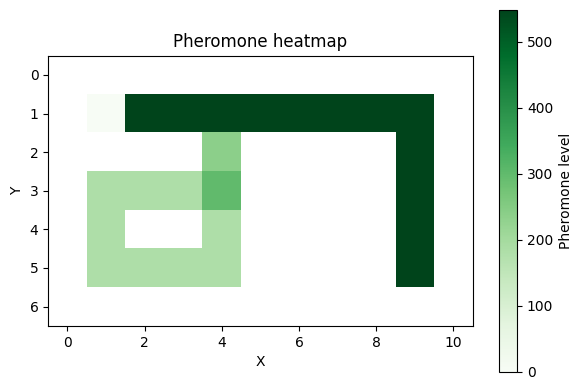


========Intelligent Ant:
Time taken: 0.195
Route size: 12


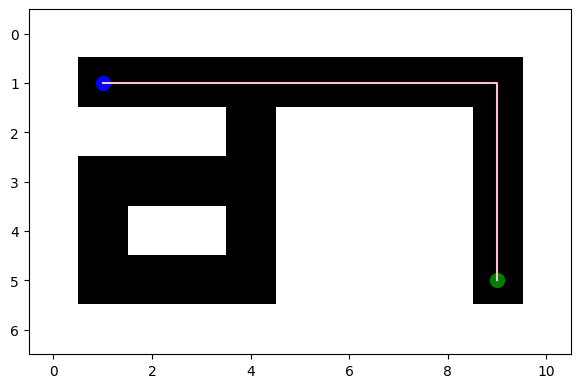

Pheromone levels at the end:


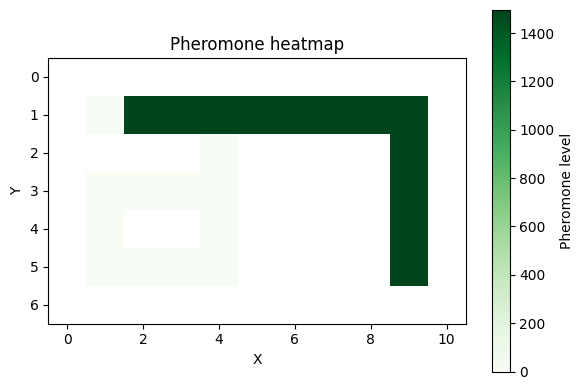


==================== dead_end_loop_maze.txt ====================
Ready reading maze file ./../data/dead_end_loop_maze.txt
========Standard Ant:
Time taken: 0.132
Route size: 12


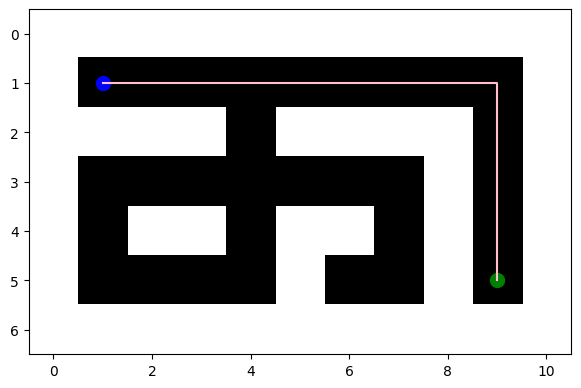

Pheromone levels at the end:


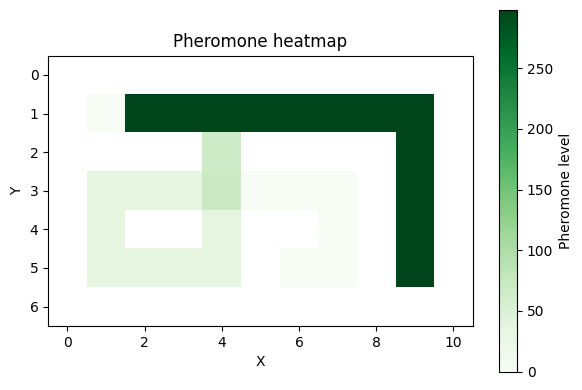


========Intelligent Ant:
Time taken: 0.24
Route size: 12


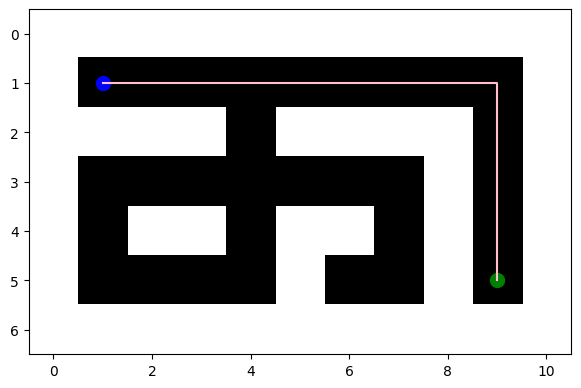

Pheromone levels at the end:


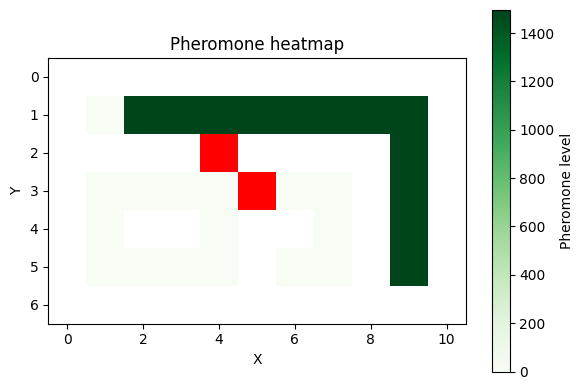

In [ ]:
test_mazes = [
    ("dead_end_maze.txt", "dead_end_coordinates.txt"),
    ("loop_maze.txt", "loop_coordinates.txt"),
    ("dead_end_loop_maze.txt", "dead_end_loop_coordinates.txt")
]

ants_per_gen = 50
no_gen = 50
q = 50
evap = 0.1
max_iter = 100
alpha = 1
beta = 2
stop_limit = 10
momentum = 1.2


for maze_file, coords_file in test_mazes:
    print(f"\n==================== {maze_file} ====================")
    maze = Maze.create_maze(f"./../data/{maze_file}")
    spec = PathSpecification.read_coordinates(f"./../data/{coords_file}")
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, momentum, intelligent_ant = False)

    print("========Standard Ant:")
    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec)

    print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
    print("Route size: " + str(shortest_route.size()))
    Visualizer.visualize_individual_path(maze, shortest_route, spec)
    print("Pheromone levels at the end:")
    maze.visualize_pheromones()
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, momentum)
    
    print("\n========Intelligent Ant:")
    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec)

    print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
    print("Route size: " + str(shortest_route.size()))
    Visualizer.visualize_individual_path(maze, shortest_route, spec)
    print("Pheromone levels at the end:")
    maze.visualize_pheromones()

##### Improvement 2: Momentum
In open areas all directions have similar pheromone levels early on, causing ants to zigzag randomly. We added a momentum multiplier that increases the probability of continuing in the same direction, mimicking how real ants walk in straighter lines.

Ready reading maze file ./../data/open_area_maze.txt

==================== momentum: 1.0 ====================
Time taken: 5.757
Route size: 32

==================== momentum: 1.5 ====================
Time taken: 3.319
Route size: 32

==================== momentum: 2.0 ====================
Time taken: 3.464
Route size: 26

==================== momentum: 3.0 ====================
Time taken: 3.574
Route size: 26

==================== momentum: 5.0 ====================
Time taken: 5.665
Route size: 26


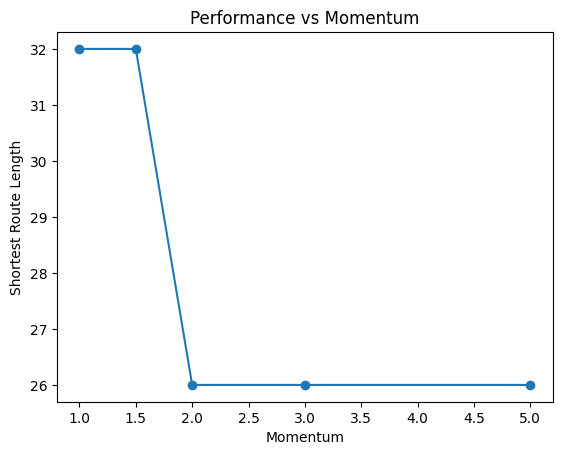

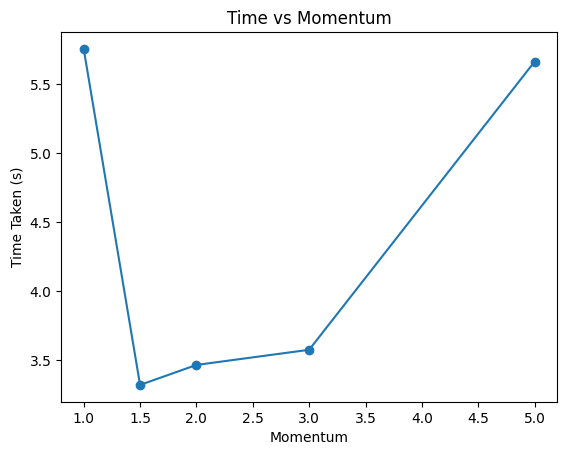

In [ ]:
momentums = [1.0, 1.5, 2.0, 3.0, 5.0]

ants_per_gen = 50
no_gen = 100
q = 500
evap = 0.1
max_iter = 200
alpha = 1
beta = 2
stop_limit = 30
maze = Maze.create_maze("./../data/open_area_maze.txt")
spec = PathSpecification.read_coordinates("./../data/open_area_coordinates.txt")

results = []
for m in momentums:
    print(f"\n==================== momentum: {m} ====================")
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, m)

    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec)

    time_taken = (int(round(time.time() * 1000)) - start_time) / 1000.0
    print("Time taken: " + str(time_taken))
    print("Route size: " + str(shortest_route.size()))
    results.append((shortest_route.size(), time_taken))

# Plot results
lengths = [r[0] for r in results]
times = [r[1] for r in results]

plt.figure()
plt.plot(momentums, lengths, marker='o')
plt.xlabel("Momentum")
plt.ylabel("Shortest Route Length")
plt.title("Performance vs Momentum")
plt.show()

plt.figure()
plt.plot(momentums, times, marker='o')
plt.xlabel("Momentum")
plt.ylabel("Time Taken (s)")
plt.title("Time vs Momentum")
plt.show()

As shown in the momentum graphs, increasing momentum from 1.0 to 2.0 reduces the route length from 32 to 26 steps on our open area test maze. The sweet spot is around 2.0-3.0 - below that ants zigzag too much, above 5.0 computation time increases again. We chose momentum=3.0 as it gives optimal route length with reasonable computation time.

### 2.5 Parameter Optimization

#### Question 16

In [ ]:
def optimize_hyperparameter(maze, spec, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, m):
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, m)

    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec)
    time_taken = (int(round(time.time() * 1000)) - start_time) / 1000.0
        
    return (shortest_route.size(), time_taken)

In [ ]:
def visualize_hyperparameter_results(param_name, param_values, results):
    lengths = [r[0] for r in results]
    times = [r[1] for r in results]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(param_values, lengths, marker='o')
    plt.xlabel(param_name)
    plt.ylabel("Shortest Route Length")
    plt.title("Performance vs " + param_name)

    plt.subplot(1, 2, 2)
    plt.plot(param_values, times, marker='o')
    plt.xlabel(param_name)
    plt.ylabel("Time Taken (s)")
    plt.title("Time vs " + param_name)

    plt.tight_layout()
    plt.show()

==================== easy_maze.txt ====================
Ready reading maze file ./../data/easy_maze.txt
======== Optimizing Ants per Generation:
 Finished ants per generation: 3/3


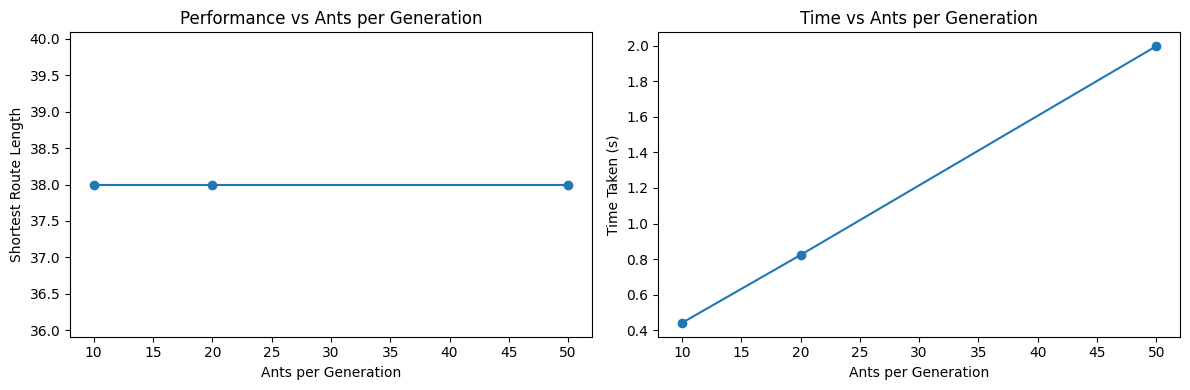

======== Optimizing Number of Generations:
 Finished number of generations: 3/3


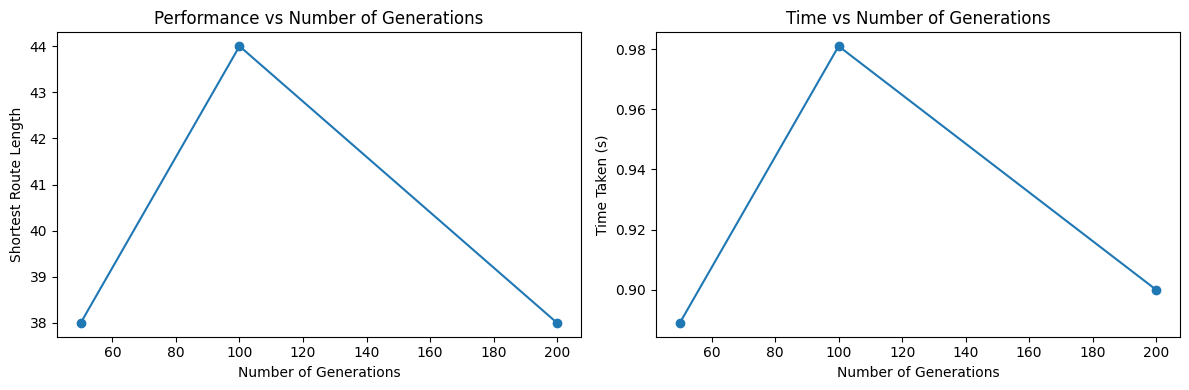

======== Optimizing Q:
 Finished Q: 3/3


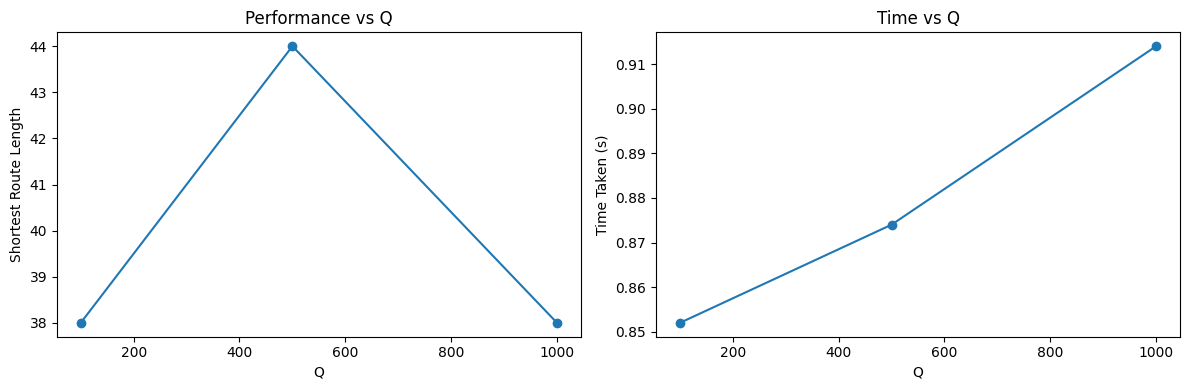

======== Optimizing Evaporation Rate:
 Finished evaporation rate: 3/3


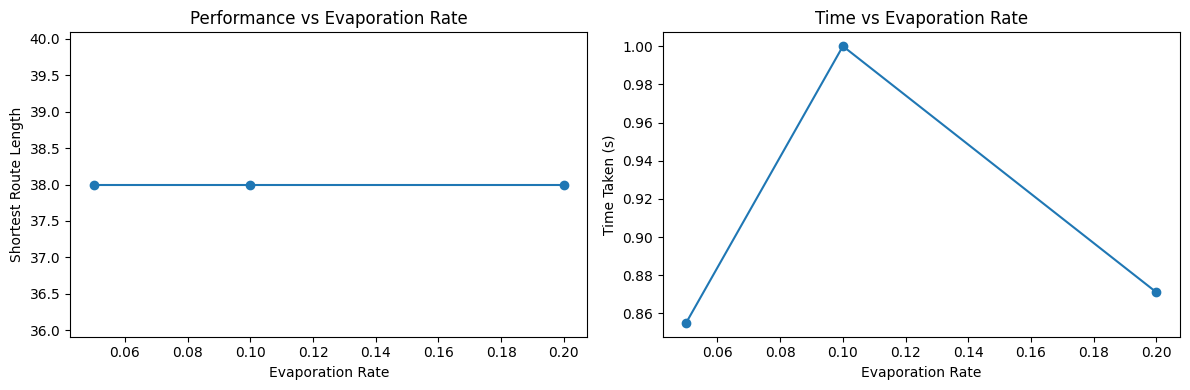

======== Optimizing Stop Limit:
 Finished stop limit: 3/3


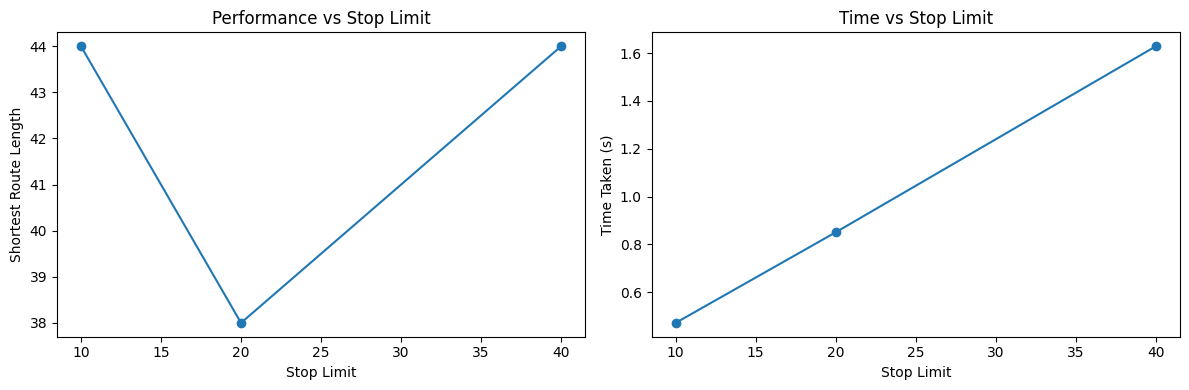

==================== medium_maze.txt ====================
Ready reading maze file ./../data/medium_maze.txt
======== Optimizing Ants per Generation:
 Finished ants per generation: 3/3


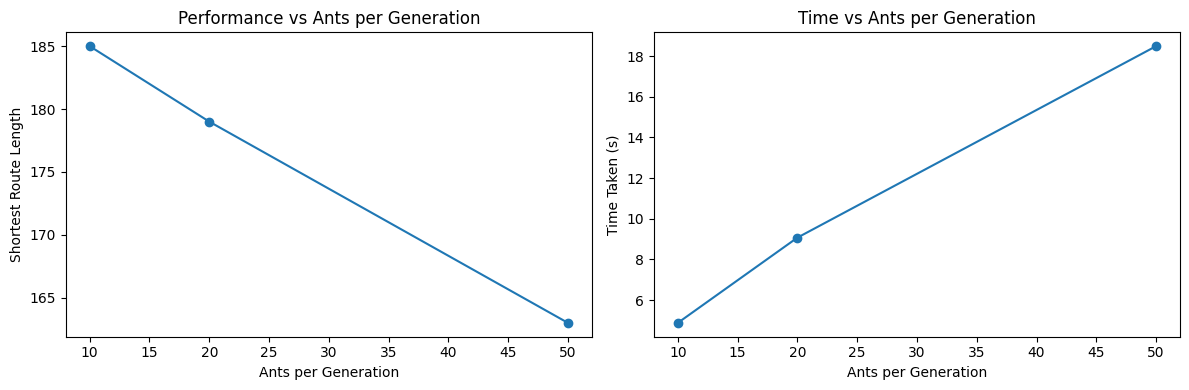

======== Optimizing Number of Generations:
 Finished number of generations: 3/3


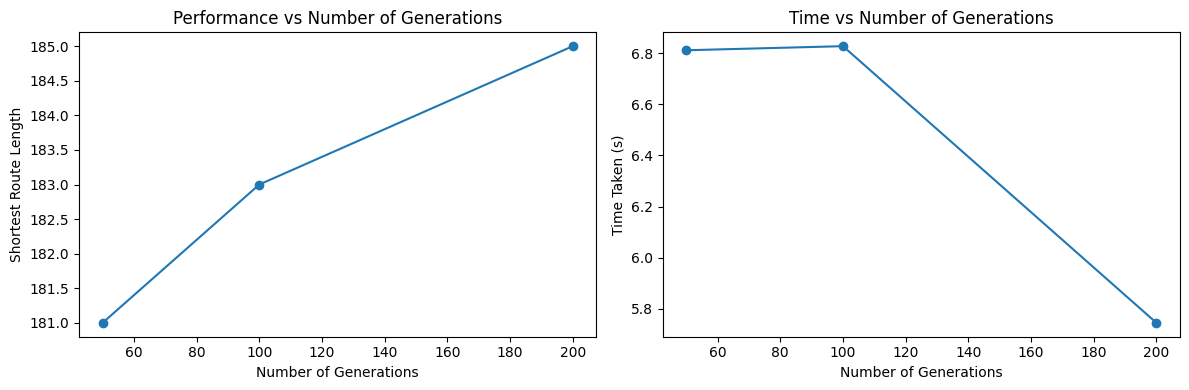

======== Optimizing Q:
 Finished Q: 3/3


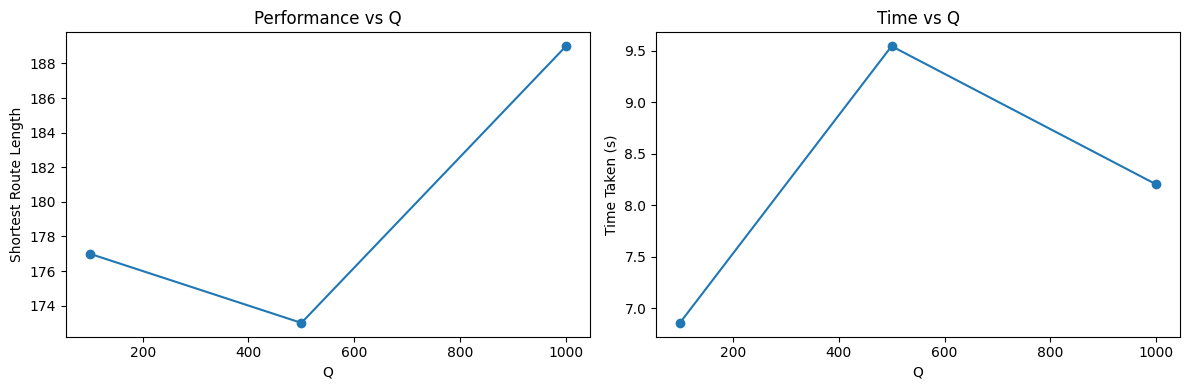

======== Optimizing Evaporation Rate:
 Finished evaporation rate: 3/3


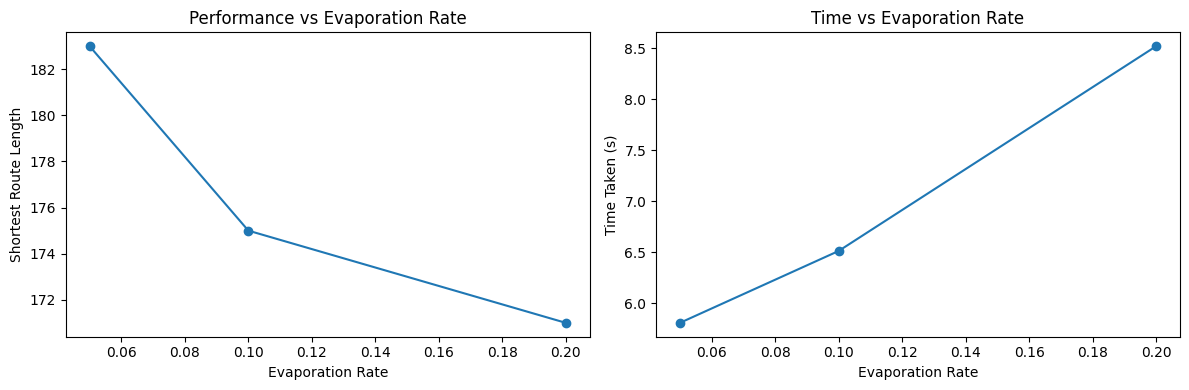

======== Optimizing Stop Limit:
 Finished stop limit: 3/3


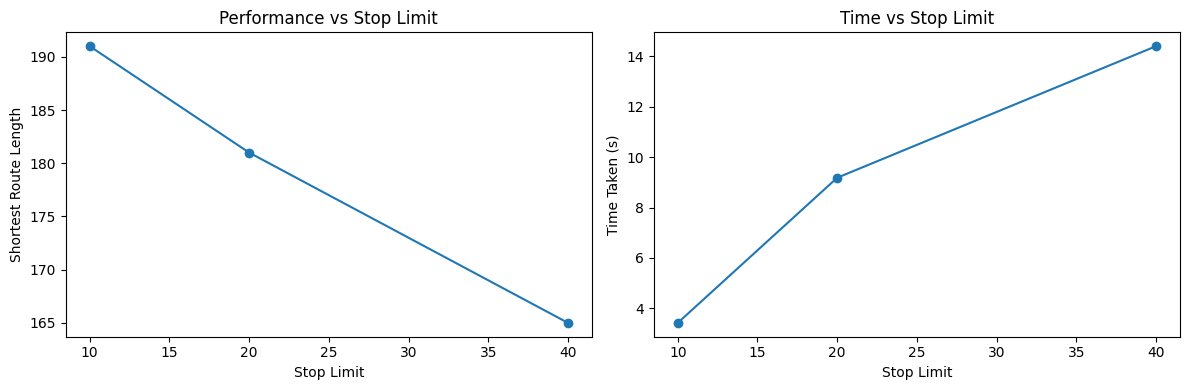

==================== hard_maze.txt ====================
Ready reading maze file ./../data/hard_maze.txt
======== Optimizing Ants per Generation:
 Finished ants per generation: 3/3


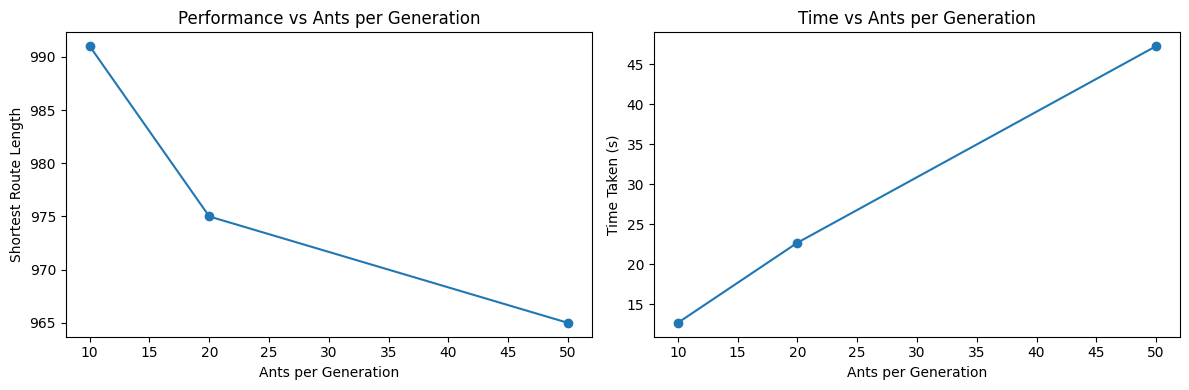

======== Optimizing Number of Generations:
 Finished number of generations: 3/3


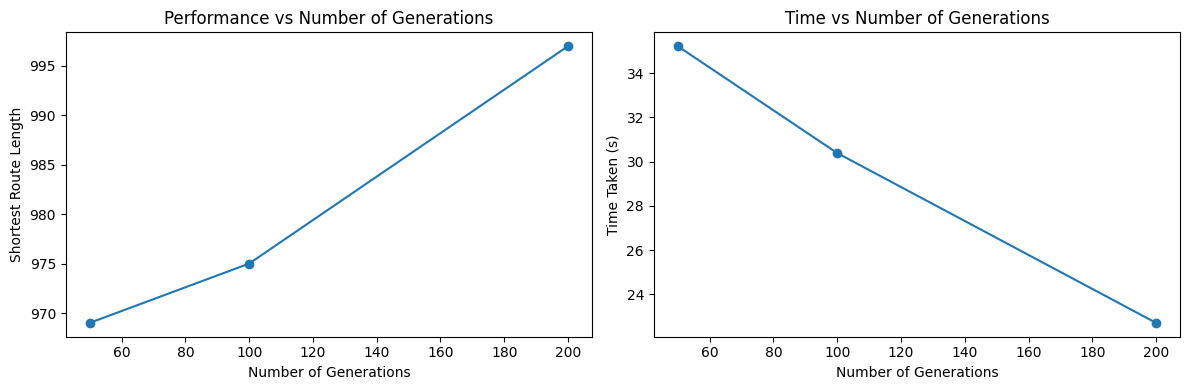

======== Optimizing Q:
 Finished Q: 3/3


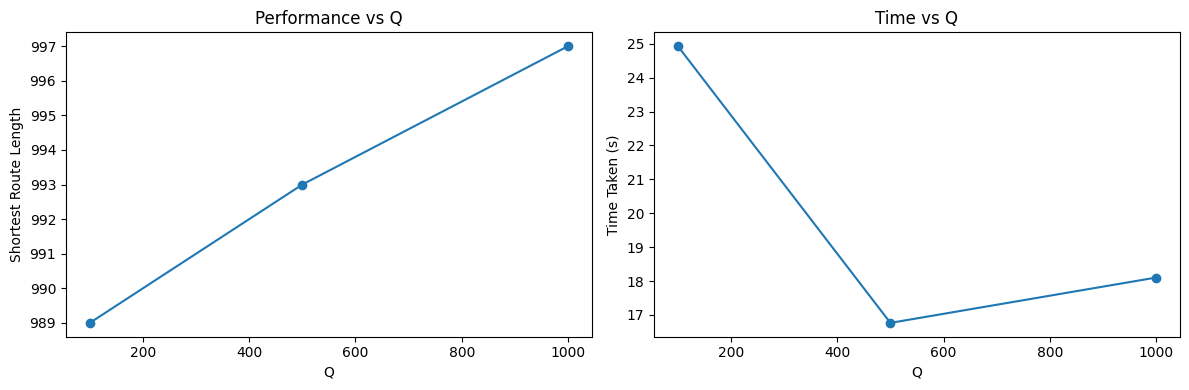

======== Optimizing Evaporation Rate:
 Finished evaporation rate: 3/3


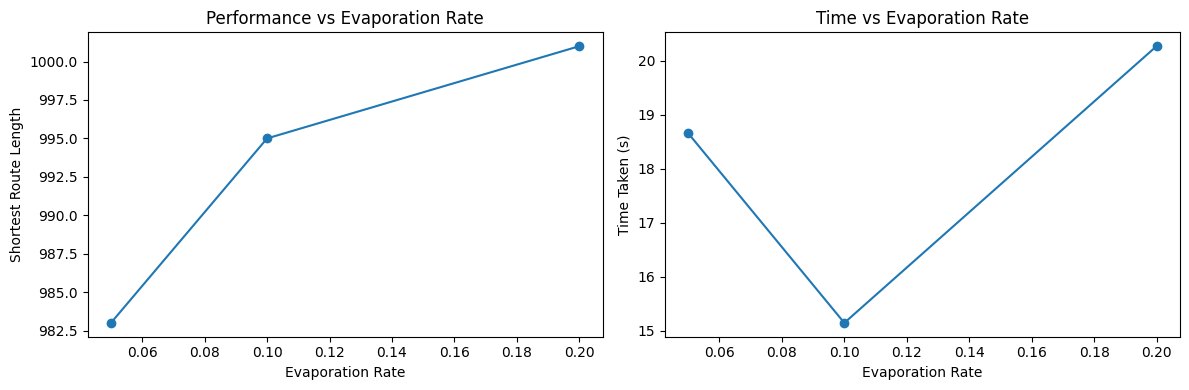

======== Optimizing Stop Limit:
 Finished stop limit: 3/3


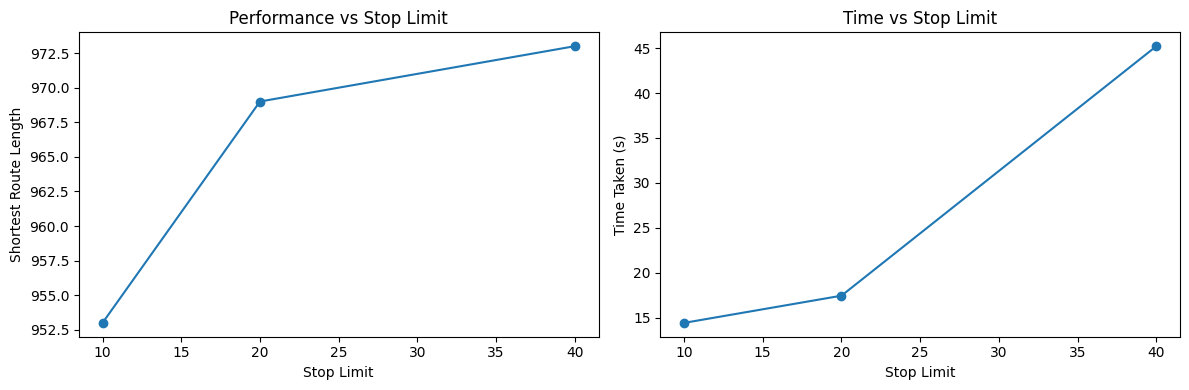

In [ ]:
test_mazes = [
    ("easy_maze.txt", "easy_coordinates.txt", [20, 100, 500, 0.1, 20]),
    ("medium_maze.txt", "medium_coordinates.txt", [20, 100, 500, 0.1, 20]),
    ("hard_maze.txt", "hard_coordinates.txt", [20, 100, 500, 0.1, 20]),
]

default_alpha = 1
default_beta = 2
default_momentum = 3

ants_per_gen = [10, 20, 50]
no_gen = [50,100, 200]
q = [100, 500, 1000]
evap = [0.05, 0.1, 0.2]
stop_limit = [10, 20, 40]


for maze_file, coords_file, default_params in test_mazes:
    default_ants_per_gen = default_params[0]
    default_no_gen = default_params[1]
    default_q = default_params[2]
    default_evap = default_params[3]
    default_stop_limit = default_params[4]
    default_max_iter = maze.get_width() * maze.get_length()

    print(f"==================== {maze_file} ====================")
    maze = Maze.create_maze(f"./../data/{maze_file}")
    spec = PathSpecification.read_coordinates(f"./../data/{coords_file}")

    print("======== Optimizing Ants per Generation:")
    results = []
    for a in ants_per_gen: 
        results.append(optimize_hyperparameter(maze, spec, a, default_no_gen, default_q, default_evap, default_alpha, default_beta, default_stop_limit, default_max_iter, default_momentum))
        print(f"\r Finished ants per generation: {ants_per_gen.index(a)+1}/{len(ants_per_gen)}", end="", flush=True)
    print()
    visualize_hyperparameter_results("Ants per Generation", ants_per_gen, results)

    print("======== Optimizing Number of Generations:")
    results = []
    for g in no_gen: 
        results.append(optimize_hyperparameter(maze, spec, default_ants_per_gen, g, default_q, default_evap, default_alpha, default_beta, default_stop_limit, default_max_iter, default_momentum))
        print(f"\r Finished number of generations: {no_gen.index(g)+1}/{len(no_gen)}", end="", flush=True)
    print()
    visualize_hyperparameter_results("Number of Generations", no_gen, results)

    print("======== Optimizing Q:")
    results = []
    for qv in q: 
        results.append(optimize_hyperparameter(maze, spec, default_ants_per_gen, default_no_gen, qv, default_evap, default_alpha, default_beta, default_stop_limit, default_max_iter, default_momentum))
        print(f"\r Finished Q: {q.index(qv)+1}/{len(q)}", end="", flush=True)
    print()
    visualize_hyperparameter_results("Q", q, results)

    print("======== Optimizing Evaporation Rate:")
    results = []
    for ev in evap: 
        results.append(optimize_hyperparameter(maze, spec, default_ants_per_gen, default_no_gen, default_q, ev, default_alpha, default_beta, default_stop_limit, default_max_iter, default_momentum))
        print(f"\r Finished evaporation rate: {evap.index(ev)+1}/{len(evap)}", end="", flush=True)
    print()
    visualize_hyperparameter_results("Evaporation Rate", evap, results)

    print("======== Optimizing Stop Limit:")
    results = []
    for sl in stop_limit: 
        results.append(optimize_hyperparameter(maze, spec, default_ants_per_gen, default_no_gen, default_q, default_evap, default_alpha, default_beta, sl, default_max_iter, default_momentum))
        print(f"\r Finished stop limit: {stop_limit.index(sl)+1}/{len(stop_limit)}", end="", flush=True)
    print()
    visualize_hyperparameter_results("Stop Limit", stop_limit, results)


To find good hyperparameters we used a one-parameter-at-a-time approach, fixing all parameters at default values and varying one at a time, recording route length and computation time for each value.

For the easy maze most parameters had little impact since the maze is simple enough that the algorithm finds the optimal route regardless.

For the medium maze evaporation rate was the most impactful. Higher evaporation (0.2) gave noticeably shorter routes by preventing the algorithm from getting stuck on suboptimal paths.

For the hard maze more ants and generations generally improved results, but we had to balance quality against speed since we need 300+ ACO runs for the TSP synthesis. We therefore chose slightly less optimal but faster parameters, compensating with a higher Q value to make pheromone deposits stronger.

Final parameters:

Easy: 
- ants_per_gen=20, no_gen=100, q=500, evap=0.1, stop_limit=20

Medium:
- ants_per_gen=50, no_gen=50, q=500, evap=0.2, stop_limit=20

Hard:
- ants_per_gen=20, no_gen=50, q=1000, evap=0.1, stop_limit=20

#### Question 17

As maze complexity and size increase, the optimal hyperparameter values change in the following ways:

Ants per generation increases with complexity (20→50→20) — more ants are needed for larger mazes to explore more paths per generation. Hard maze ants_per_gen is kept low to make it faster.

Number of generations decreases (100→50→50) — combined with higher evaporation on medium, the algorithm converges faster so fewer generations are needed.

Q increases with complexity (500→500→1000) — larger mazes have longer routes so a higher Q is needed to keep pheromone deposits strong enough to guide ants.

Evaporation rate increases then stays (0.1→0.2→0.1) — medium maze benefits from faster evaporation to avoid premature convergence, while hard maze needs trails to persist longer due to the much longer paths.

Stop limit stays constant (20→20→20) — early stopping at 20 works well across all mazes since combined with the other parameters the algorithm converges reliably within that window.


### 2.6 The Final Route

#### Question 18


==================== easy ====================
Ready reading maze file ./../data/easy_maze.txt

========Intelligent Ant:
Time taken: 0.806
Route size: 44


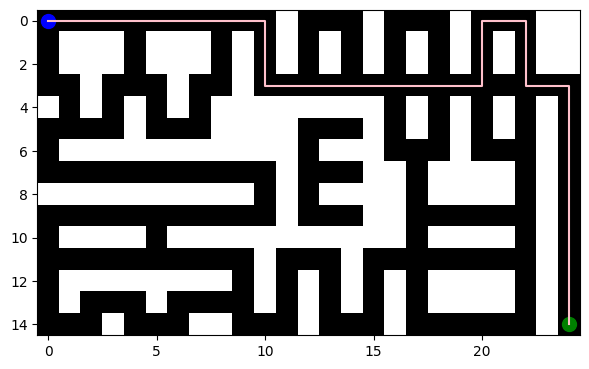


==================== medium ====================
Ready reading maze file ./../data/medium_maze.txt

========Intelligent Ant:
Time taken: 17.084
Route size: 179


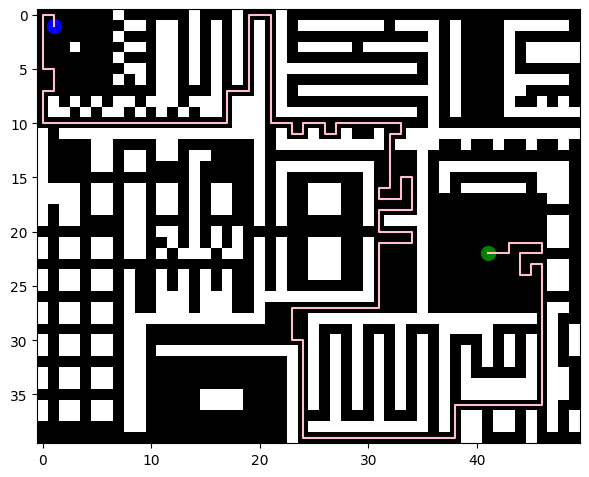


==================== hard ====================
Ready reading maze file ./../data/hard_maze.txt

========Intelligent Ant:
Time taken: 37.176
Route size: 995


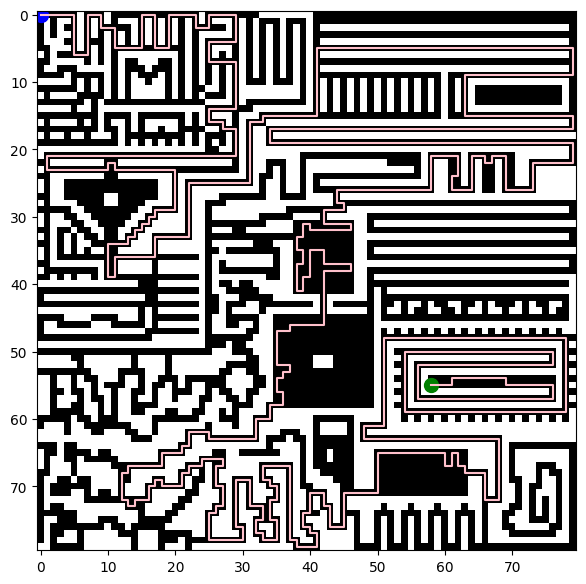

In [ ]:
mazes = [
    ("easy", [20, 100, 500, 0.1, 20]),
    ("medium", [50, 50, 500, 0.2, 20]),
    ("hard", [20, 50, 1000, 0.1, 20]),
]

alpha = 1
beta = 2
momentum = 3


for difficulty, default_params in mazes:
    ants_per_gen = default_params[0]
    no_gen = default_params[1]
    q = default_params[2]
    evap = default_params[3]
    stop_limit = default_params[4]

    print(f"\n==================== {difficulty} ====================")
    maze = Maze.create_maze(f"./../data/{difficulty}_maze.txt")
    spec = PathSpecification.read_coordinates(f"./../data/{difficulty}_coordinates.txt")
    max_iter = maze.get_width() * maze.get_length()
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, alpha, beta, stop_limit, max_iter, momentum)
    
    print("\n========Intelligent Ant:")
    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec)

    print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
    print("Route size: " + str(shortest_route.size()))
    Visualizer.visualize_individual_path(maze, shortest_route, spec)
    shortest_route.write_to_file(f"./../data/68_{difficulty}.txt")

    

### 2.7 Synthesis

#### Question 19

In [ ]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 20
no_gen = 50
q = 1000
evap = 0.1
generations = 100
population_size = 50

tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap, alpha=1, beta=2, stop_limit=40, max_ant_iter=maze.get_width() * maze.get_length(), momentum=3)

# Run optimization and write to file
tsp_data.calculate_routes(aco)

Ready reading maze file ./../data/hard_maze.txt


KeyboardInterrupt: 

In [ ]:

persist_file = "./../tmp/my_tsp_with_ACO"
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

population_size = 50
generations = 5000
random.seed(50)
mutation_prob = 0.1
crossover_prob = 0.8

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size, mutation_prob, crossover_prob)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/my_tsp_solution_with_ACO.txt")

True


In [ ]:
print(solution)

[0, 1, 6, 4, 13, 3, 15, 8, 7, 17, 9, 14, 11, 12, 5, 10, 2, 16]


The order of products from the GA in Part 1 and the one using ACO distances are almost the same. There are only small differences, products #4 and #16, and #8 and #18 being swapped (indices 3/15 and 7/17).

So overall, the fitness of the solution is very similar. For the fitness, Part 1 got 1343, while the ACO version got 1461, which is about 9% worse. Since lower is better, the original solution is better. But this kind of difference makes sense because ACO is using estimated distances, not exact ones. Even with that, the order of products is nearly identical, which means ACO is still capturing the relative distances quite well. 

The difference in fitness isn’t that big considering the problem size. Overall, the result is pretty good. ACO doesn’t give the exact best path, but it gets close enough to reproduce almost the same order, which is what we needed here.


## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

Consider using a genetic algorithm to design the optimal geometry for a racing bicycle and the racer's posture. The goal is to minimize race time, which requires a balance of minimal air resistance, maximal biomechanical power output, rider comfort to delay fatigue and various other factors. Because the goal cannot be expressed as a single mathematical formula, engineers must use a proxy fitness function, and we don't know if this fitness function is the absolutely correct one.

Because the GA is a blind optimizer, it will exploit this function without any common sense. To achieve the goal, the algorithm might evolve an extreme bicycle geometry that forces the rider to lie completely flat on their stomach over the front wheel. While this chromosome receives a mathematically perfect fitness score in the simulation, it causes severe real-world problems: the racer cannot physically pedal from that position, they cannot see the track, and the bike would be practically impossible to steer. The fitness function caused the algorithm to successfully solve the math problem while completely failing the engineering problem by ignoring the human and physical constraints of the sport.

#### Question 21

We do not always want only the strongest individuals to survive because it leads to premature convergence. If the absolute fittest individuals are guaranteed to survive and reproduce, their genes will instantly flood the population. The gene pool loses its diversity almost immediately, causing the entire population to get trapped on a local optimum. We need weaker individuals to survive because they carry unique, outlier genetic material that might be needed later to cross a valley and discover the global optimum. 

To prevent the strongest from completely taking over the gene pool, we use probabilistic selection mechanisms that balances exploitation and exploration.
1. Tournament Selection: Instead of ranking the entire population and taking the top half, the algorithm randomly picks a small subset of individuals to compete in a tournament. Only the strongest individual within that specific subset survives or reproduces. If the tournament size is kept small, a globally weak individual still has a chance to survive if it happens to be randomly matched against even weaker individuals.
2. Rank Selection: Sometimes, a single individual appears with a fitness score mathematically 100x higher than the rest of the population. In a standard roulette wheel, this individual would take up 99% of the survival probability. Rank Selection mitigates this by completely ignoring the raw fitness scores. Instead, the population is sorted from worst to best, and survival probability is assigned purely based on this rank. This artificially caps the dominance of the strongest individual, ensuring a smoother probability distribution where weaker individuals still retain a meaningful chance to pass on their genes. 


### 3.2 Pen and Paper

#### Question 22

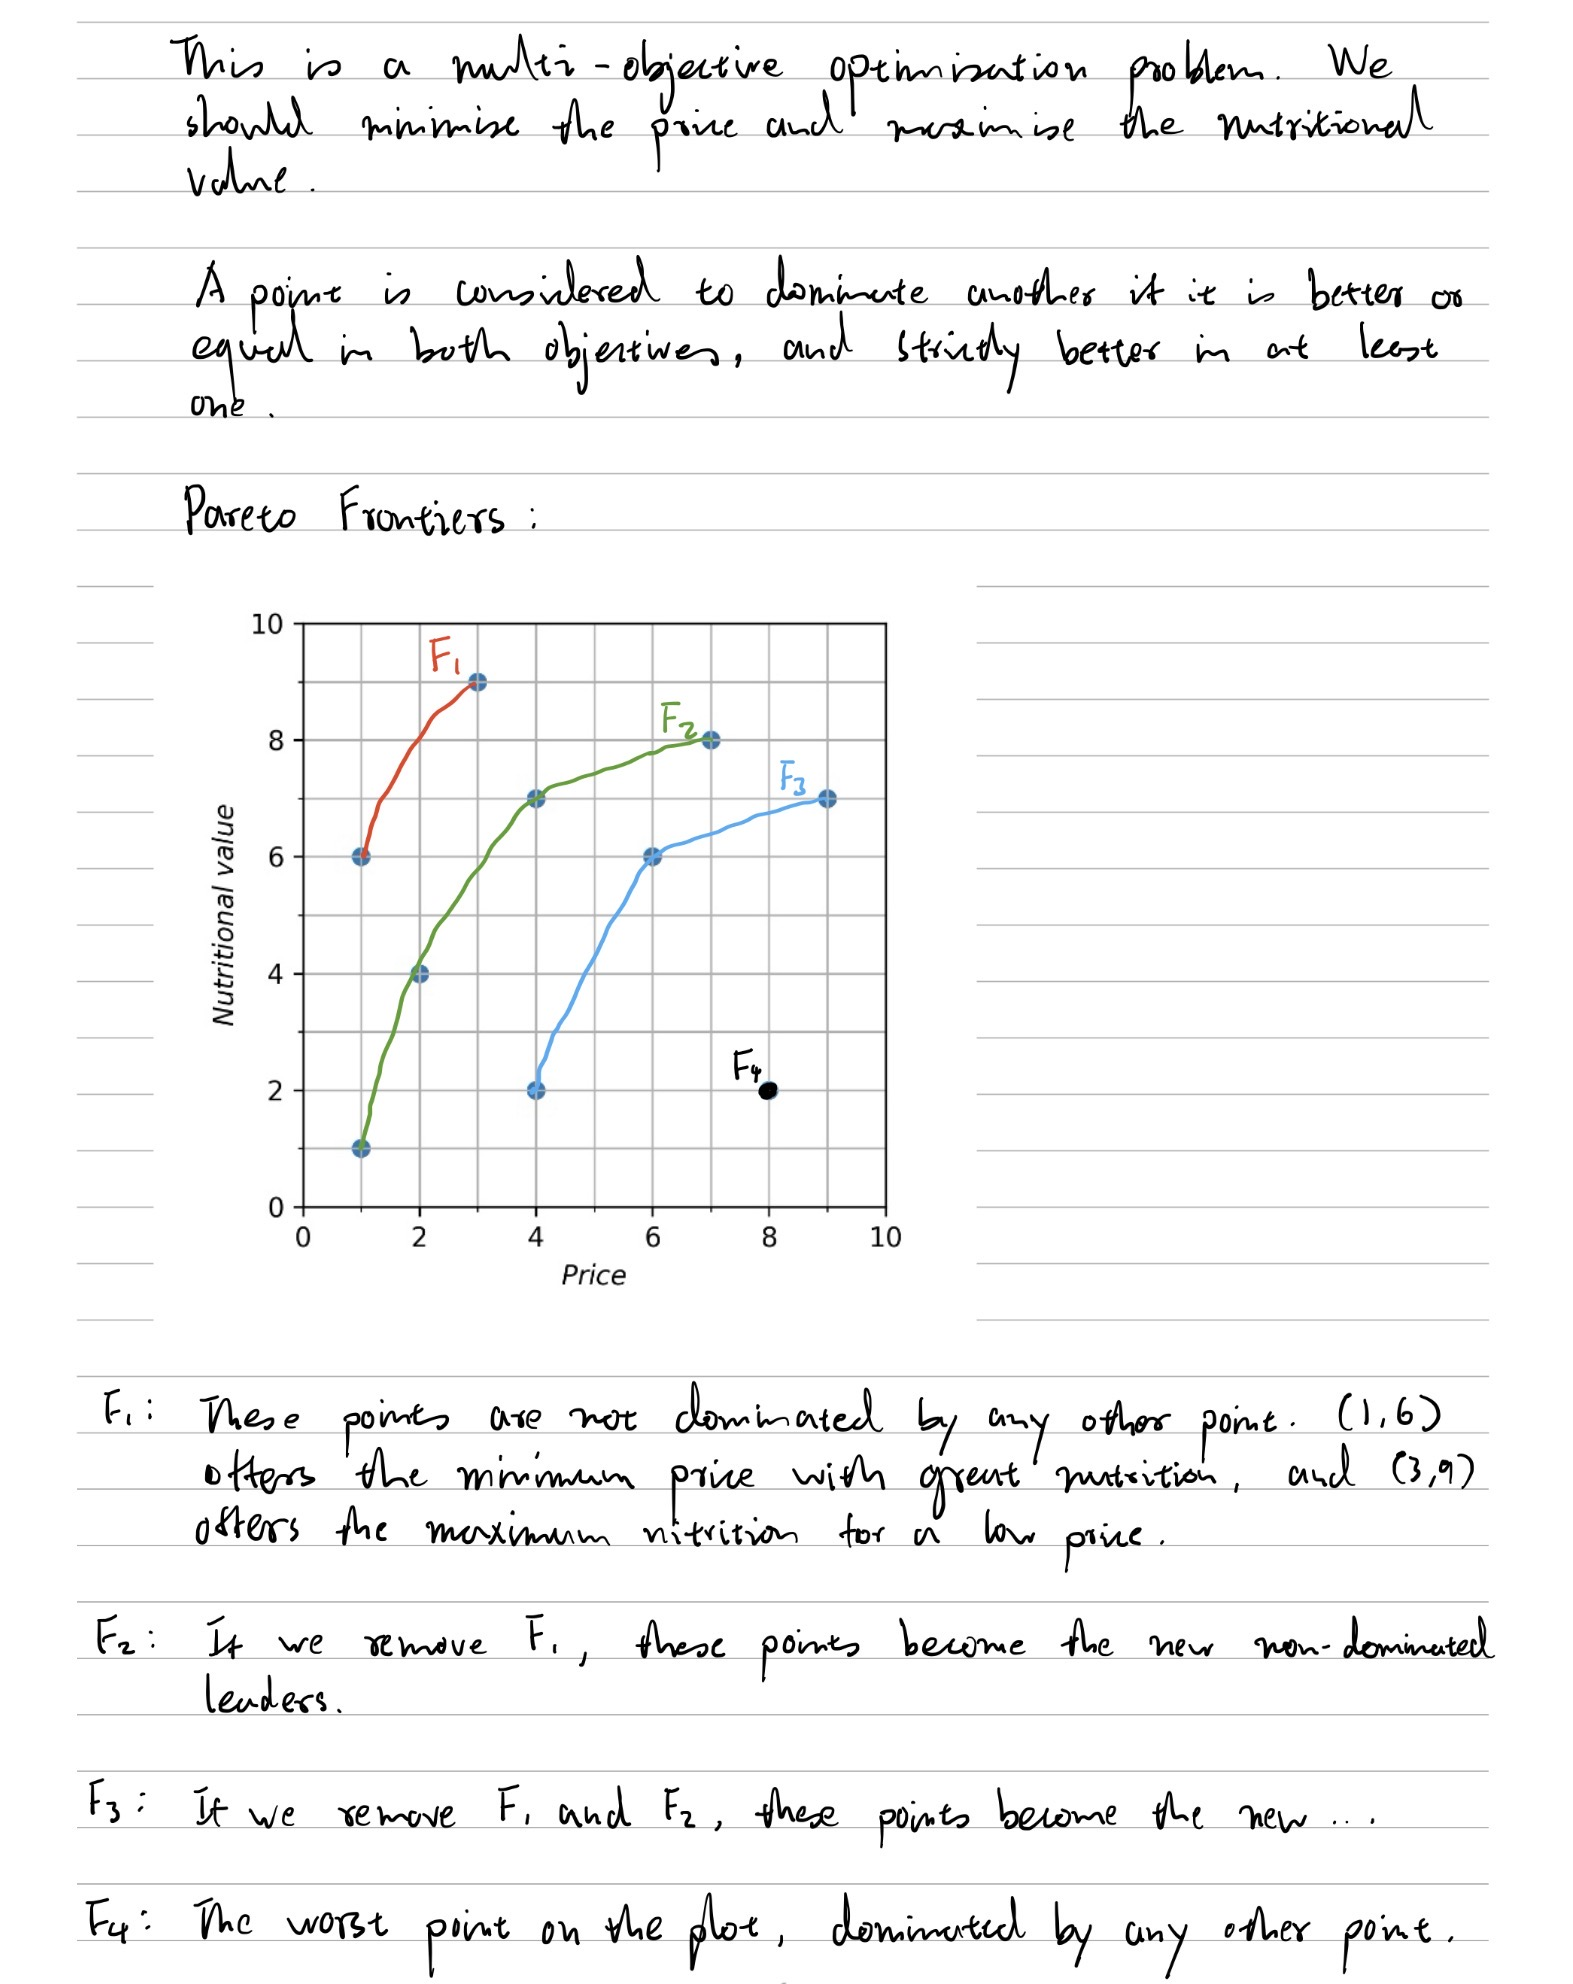

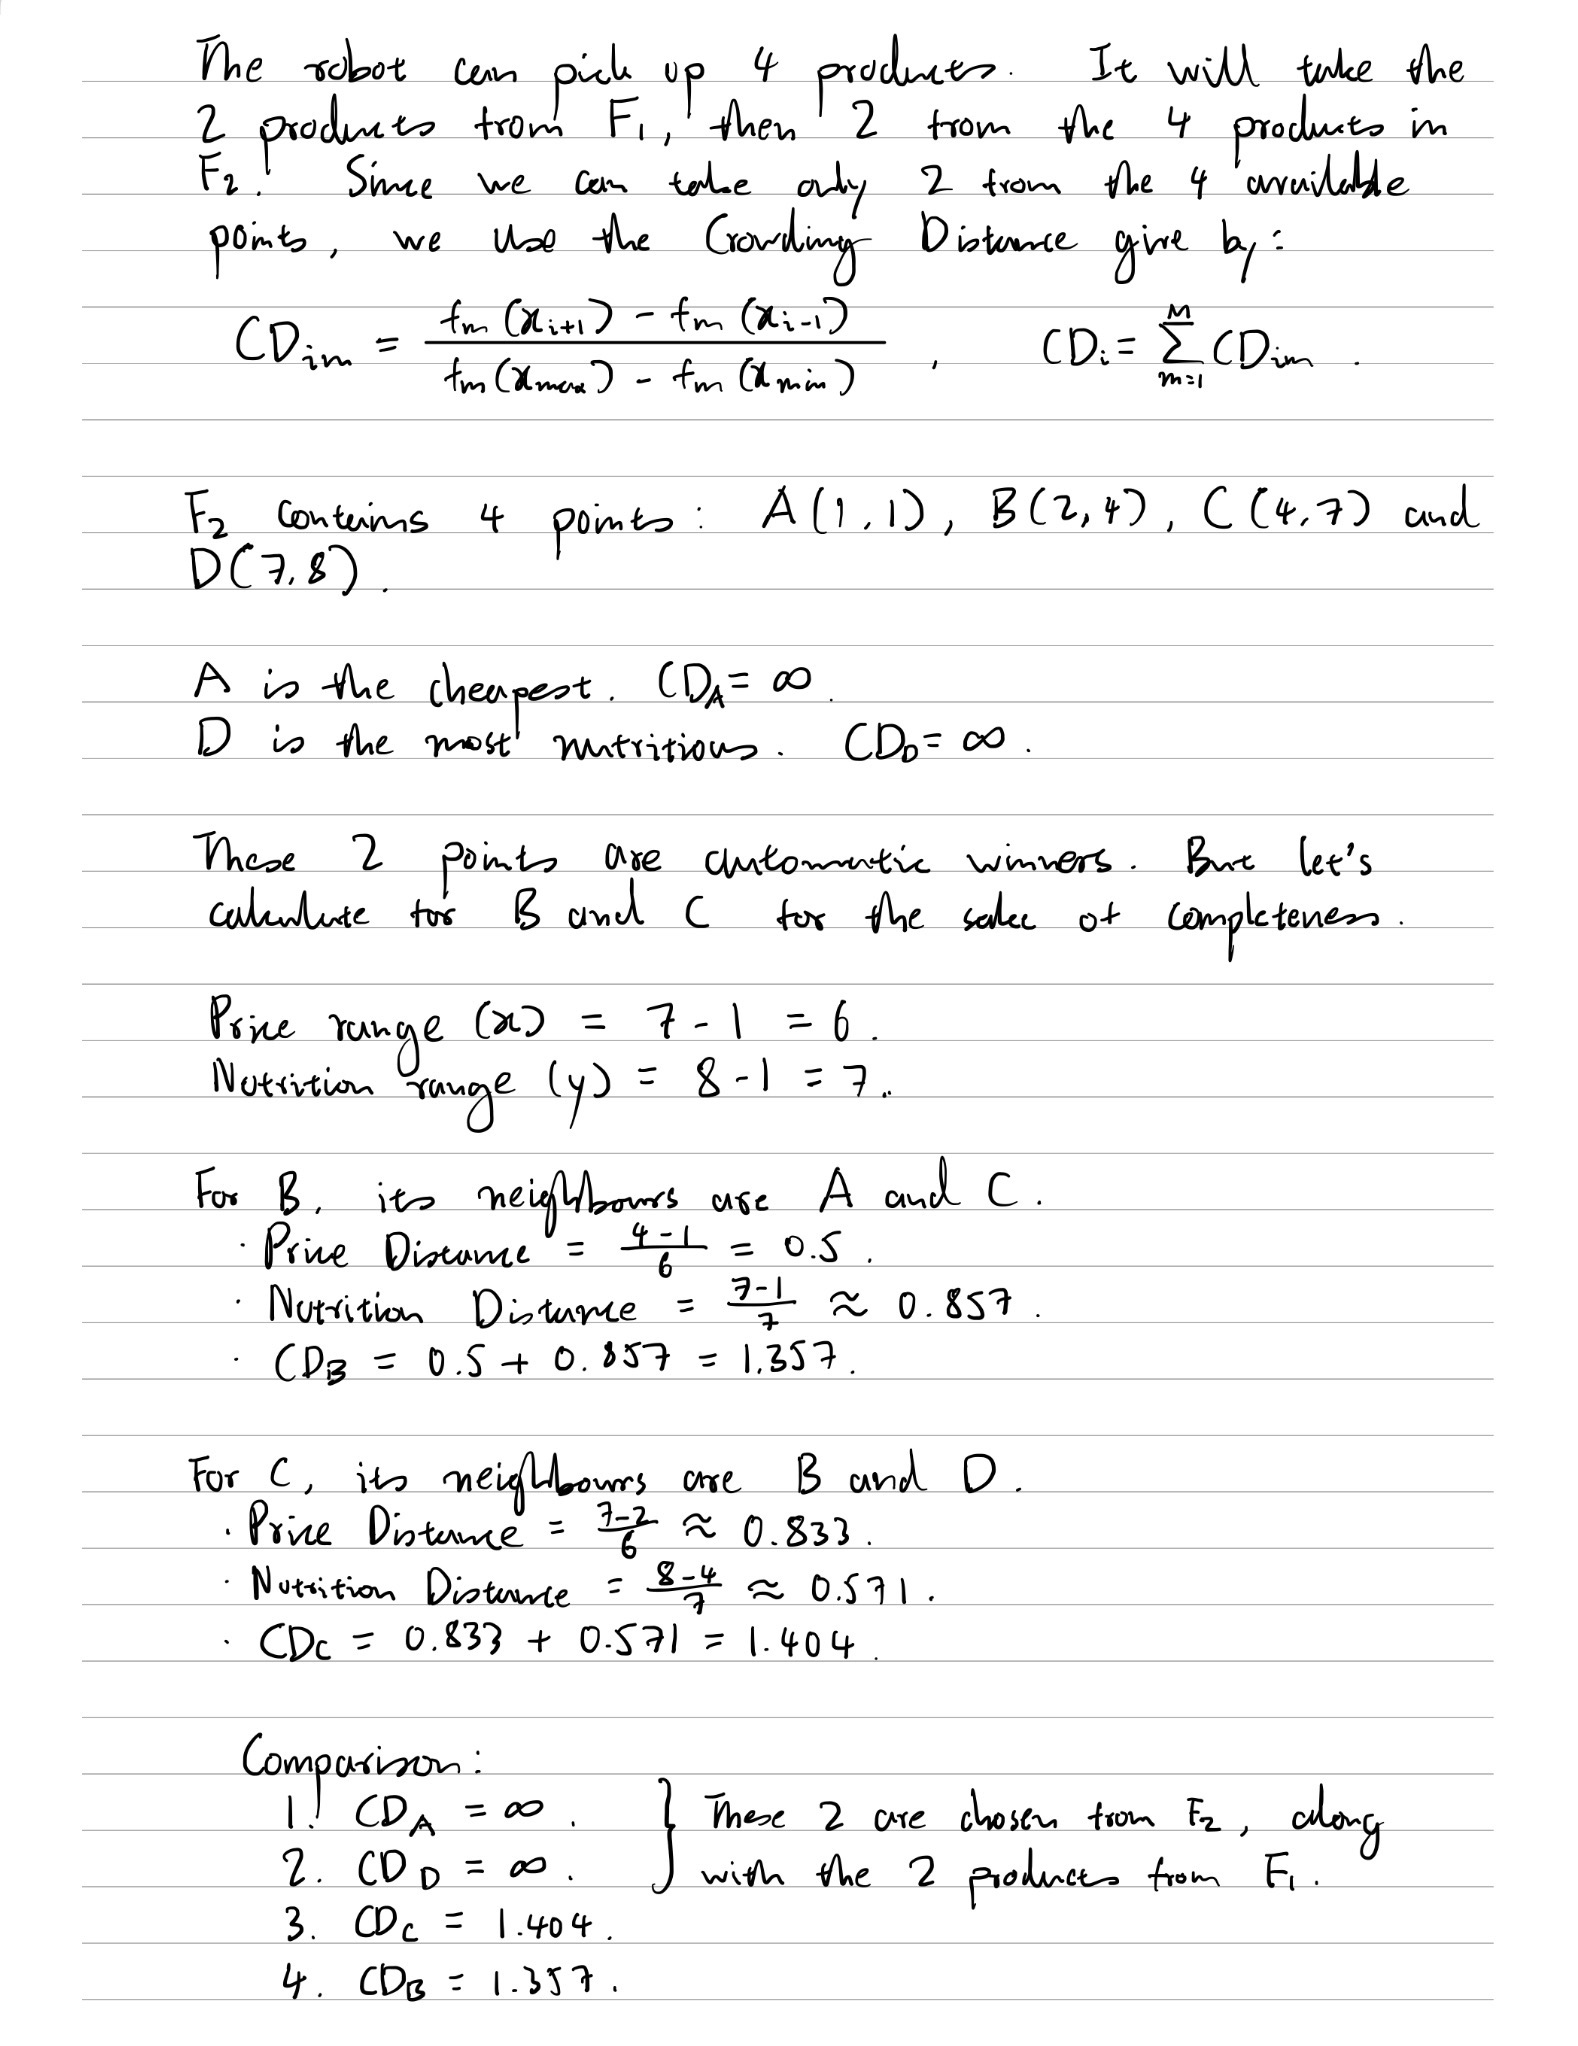

### 3.3 Division of Work

#### Question 23

|          Component          |  Tushit   |  Lukas   |  Xianfei   |  Alex   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     30%     |     30%     |     15%     |     25%     |
| Code (implementation)       |     30%     |     35%     |     10%     |     25%     |
| Code (validation)           |     20%     |     20%     |     30%     |     30%     |
| Experiments (execution)     |     30%     |     30%     |     20%     |     20%     |
| Experiments (analysis)      |     30%     |     30%     |     20%     |     20%     |
| Experiments (visualization) |     15%     |     35%     |     30%     |     20%     |
| Report (original draft)     |     25%     |     15%     |     35%     |     25%     |
| Report (reviewing, editing) |     20%     |     15%     |     35%     |     30%     |

### References

- Hussain, A., Muhammad, Y. S., Sajid, M. N., Hussain, I., Shoukry, A. M., & Gani, S. (2017). Genetic Algorithm for Traveling Salesman Problem with Modified Cycle Crossover Operator. Computational Intelligence and Neuroscience, 2017, 1–7. https://doi.org/10.1155/2017/7430125